**RDGY41710** Practical Session: eXplainable AI, SHAP

June, 2024

In [1]:
# import statements
import tensorflow as tf
from tensorflow import keras
from keras.layers import Input

In [2]:
# CIFAR-10 dataset loading and normalization
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

x_train = x_train/255.
x_test = x_test/255.

170498071/170498071 [==============================] - 4s 0us/step


In [3]:
# Model design

input = tf.keras.Input(shape=(32, 32, 3))
x = tf.keras.layers.Conv2D(32, (3,3), activation='relu',padding='same')(input)
x = tf.keras.layers.MaxPooling2D(2)(x)
x = tf.keras.layers.Conv2D(128, (3,3), activation='relu',padding='same')(x)
x = tf.keras.layers.MaxPooling2D(2)(x)
x = tf.keras.layers.Dropout(0.4)(x)
x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.Dense(256, activation='relu')(x)
x = tf.keras.layers.Dense(10)(x)
output= tf.keras.activations.softmax(x)
model = tf.keras.Model(inputs=input, outputs=output,name="Cifar_10.Model")
model.summary()

Model: "Cifar_10.Model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 32, 32, 3)]       0         
                                                                 
 conv2d (Conv2D)             (None, 32, 32, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 16, 16, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 16, 16, 128)       36992     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 8, 8, 128)         0         
 g2D)                                                            
                                                                 
 dropout (Dropout)           (None, 8, 8, 128)      

In [4]:
# model compiling
initial_learning_rate = 0.0001
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate,
    decay_steps=10000,
    decay_rate=0.96,
    staircase=True)

model.compile(loss=tf.losses.SparseCategoricalCrossentropy(),optimizer=tf.optimizers.Adam(learning_rate=lr_schedule), metrics=['accuracy'])

In [5]:
# model training
model.fit(x_train, y_train, batch_size=100, epochs=5, validation_split=0.2)

Epoch 1/5
400/400 [==============================] - 8s 9ms/step - loss: 1.8116 - accuracy: 0.3587 - val_loss: 1.5600 - val_accuracy: 0.4555
Epoch 2/5
400/400 [==============================] - 3s 8ms/step - loss: 1.4738 - accuracy: 0.4788 - val_loss: 1.4034 - val_accuracy: 0.5099
Epoch 3/5
400/400 [==============================] - 4s 9ms/step - loss: 1.3389 - accuracy: 0.5296 - val_loss: 1.3128 - val_accuracy: 0.5410
Epoch 4/5
400/400 [==============================] - 4s 9ms/step - loss: 1.2505 - accuracy: 0.5608 - val_loss: 1.2180 - val_accuracy: 0.5823
Epoch 5/5
400/400 [==============================] - 3s 9ms/step - loss: 1.1901 - accuracy: 0.5846 - val_loss: 1.1866 - val_accuracy: 0.5941


In [6]:
# model evaluation
model.evaluate(x_test, y_test, verbose=2)

313/313 - 1s - loss: 1.1709 - accuracy: 0.5954 - 1s/epoch - 3ms/step


[1.170939564704895, 0.5953999757766724]

In [7]:
# install SHAP
# SHAP manual can be found at the following link: https://shap-lrjball.readthedocs.io/en/latest/index.html
# We install and import SHAP here because it requires specific version of tensorflow that can impact the model training and evaluation functions
!pip install shap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 540.1/540.1 kB 6.1 MB/s eta 0:00:00


In [8]:
import numpy as np
import shap
import matplotlib.pyplot as plt

In [9]:
# get ten images to plot sample SHAP values: one example image per category
x_test_dict = {}
y_test_select = []
for i, l in enumerate(y_test):
  if len(x_test_dict)==10:
    break
  if str(l) not in x_test_dict:
    x_test_dict[str(l)] = x_test[i]
    y_test_select.append(l)
x_test_each_class = [x_test_dict[i] for i in sorted(x_test_dict)]
y_test_select = sorted(y_test_select)
x_test_each_class = np.asarray(x_test_each_class)

In [10]:
# select backgroud for shap
# x_train = x_train.reshape(50000, 32, 32, 3)
data = x_train[np.random.choice(x_train.shape[0], 1000, replace=False)]# DeepExplainer to explain predictions of the model
explainer = shap.DeepExplainer(model, data)# compute shap values
shap_values = explainer.shap_values(x_test_each_class)

/usr/local/lib/python3.10/dist-packages/shap/explainers/_deep/deep_tf.py:99: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn("Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.")
/usr/local/lib/python3.10/dist-packages/keras/src/backend.py:452: UserWarning: `tf.keras.backend.set_learning_phase` is deprecated and will be removed after 2020-10-11. To update it, simply pass a True/False value to the `training` argument of the `__call__` method of your layer or model.
  warnings.warn(


In [30]:
shap_values.shape

(10, 32, 32, 3, 10)

In [33]:
shap_numpy = list(np.transpose(shap_values, (4, 0, 1, 2, 3)))

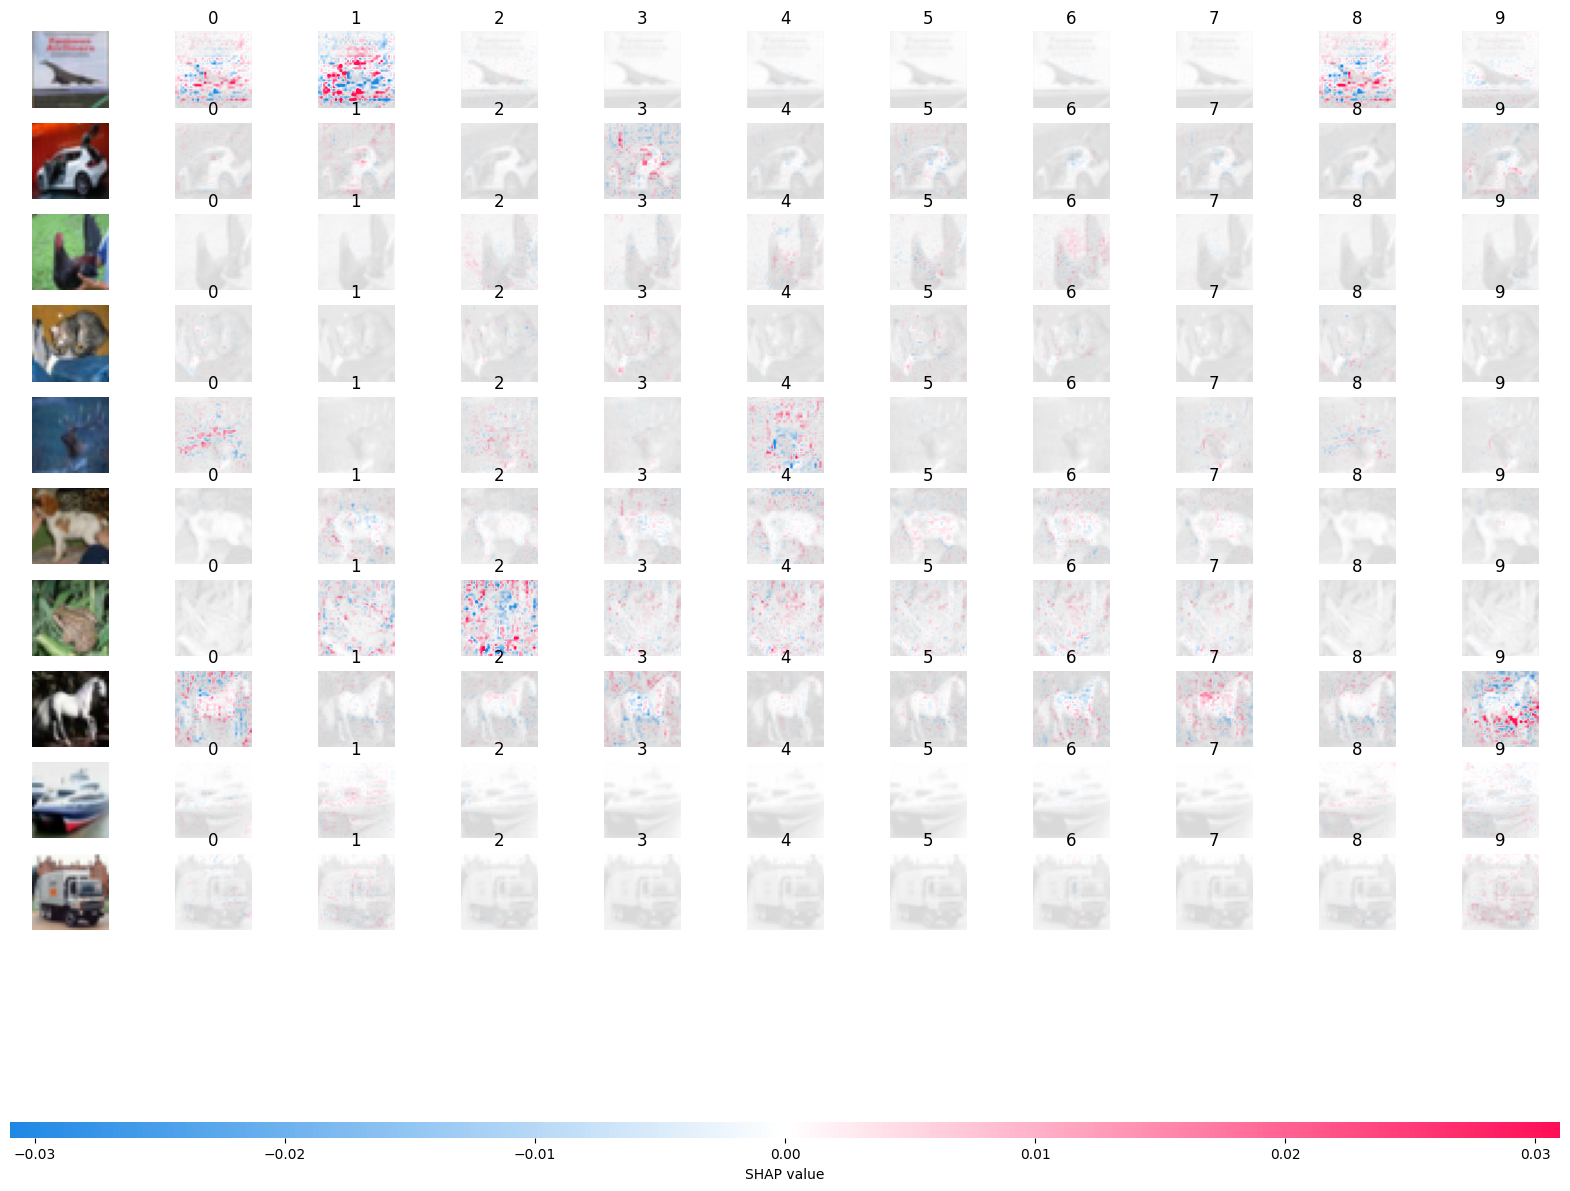

In [34]:
# plot SHAP values
# this will plot the test images on the left column, and the categories found on the dataset will be listed from the second to the last column
# red pixels on the images under the categories represent positive SHAP values that contributed to classifying the image on the left as that category
# blue pixels represent negative SHAP values that contributed against classifying the image on the left as that category
shap.image_plot(shap_numpy, x_test_each_class, np.repeat(np.array(y_test_select).flatten().reshape((1, 10)), [10], axis=0))